## Simulating traffic around a lock (with hydrodynamics)
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph. Vessels are locked together if they can fit inside the lock, and arrive within the clustering time window. Changing water levels are implemented, which influences the duration of the levelling.

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from scipy.stats import norm, uniform, expon

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# packege(s) needed to create hydrodynamic data
import xarray as xr

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-350600,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(350600,0)))

# add edges
graph.add_edge('-1','0', weight=1)
graph.add_edge('0','-1', weight=1)
graph.add_edge('0','1', weight=1)
graph.add_edge('1','0', weight=1)
graph.add_edge('1','+1', weight=1)
graph.add_edge('+1','1', weight=1)


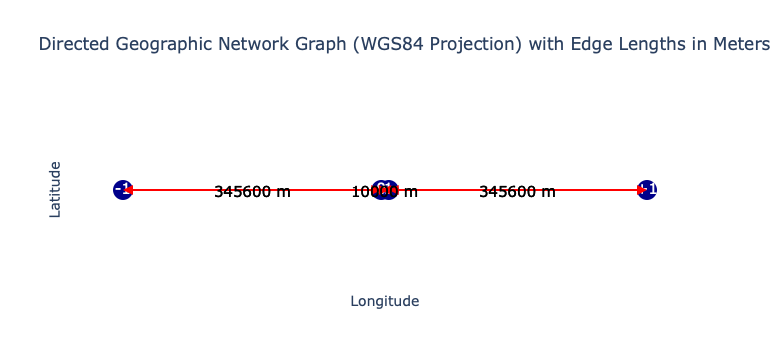

In [4]:
opentnsim.graph.plot_graph(graph)

#### 3. Run simulation

In [5]:
def generate_vessel(
    env,
    name,
    start_node,
    end_node,
    arrival_time,
    vessel_speed=4,
    vessel_length=100,
    vessel_beam=20,
    vessel_draft=10,
    vessel_type="tanker"):
    """
    Creates and returns a Vessel object with a computed route through the environment graph.

    Parameters:
    ----------
    env : Environment
        The simulation environment containing the graph and other context.
    name : str
        Human readabile identifier for the vessel.
    start_node : str or int
        The starting node in the graph (converted to string).
    end_node : str or int
        The destination node in the graph (converted to string).
    arrival_time : pd.Timestamp
        The scheduled arrival time of the vessel at the start node.
    vessel_speed : float, optional
        Speed of the vessel in knots or simulation units (default is 4).
    vessel_length : float, optional
        Length of the vessel in meters (default is 100).
    vessel_beam : float, optional
        Beam (width) of the vessel in meters (default is 20).
    vessel_draft : float, optional
        Draught (depth below waterline) of the vessel in meters (default is 10).
    vessel_type : str, optional
        Type of vessel (e.g., "tanker", "cargo", "container") (default is "tanker").

    Returns:
    -------
    Vessel or None
        A Vessel object initialized with the given parameters and route.
        Returns None if no valid path exists between start_node and end_node.
    """
    
    # Ensure nodes are strings
    start_node = str(start_node)
    end_node = str(end_node)

    try:
        route = nx.dijkstra_path(env.graph, start_node, end_node)
    except nx.NetworkXNoPath:
        print(f"⚠️ No path from {start_node} to {end_node}. Vessel {name} not created.")
        return None

    geometry = env.graph.nodes[start_node]['geometry']

    data_vessel = {
        "env": env,
        "name": name,
        "geometry": geometry,
        "route": route,
        "v": vessel_speed,
        "L": vessel_length,
        "B": vessel_beam,
        "T": vessel_draft,
        "type": vessel_type,
        "arrival_time": arrival_time,
    }

    vessel = Vessel(**data_vessel)

    return vessel

In [6]:
def generate_vessels_with_distributions(
    env,
    num_vessels,
    start_time,
    arrival_dist_up=None,
    arrival_dist_down=None,
    seed_up=None,
    seed_down=None):
    """
    Generates a list of vessels with interarrival times drawn from specified distributions
    for upward and downward directions. Supports independent seeding for reproducibility.

    Parameters
    ----------
    env : Environment
        The simulation environment containing the graph and vessel context.
    num_vessels : int
        Total number of vessels to generate. Vessels alternate between up and down directions.
    start_time : pd.Timestamp
        The initial timestamp from which vessel arrivals begin.
    arrival_dist_up : callable, optional
        A function returning interarrival times (in minutes) for upward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    arrival_dist_down : callable, optional
        A function returning interarrival times (in minutes) for downward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    seed_up : int or None, optional
        Seed for the random number generator used in upward direction.
    seed_down : int or None, optional
        Seed for the random number generator used in downward direction.

    Returns
    -------
    list of Vessel
        A list of Vessel objects with assigned routes and arrival times.
        Vessels for which no valid path exists are skipped.
    """

    vessels = []

    # Create independent random generators
    rng_up = np.random.default_rng(seed_up)
    rng_down = np.random.default_rng(seed_down)

    # Default to exponential distribution with mean 20 minutes
    if arrival_dist_up is None:
        arrival_dist_up = lambda: rng_up.exponential(scale=20)
    if arrival_dist_down is None:
        arrival_dist_down = lambda: rng_down.exponential(scale=20)

    up_time = start_time
    down_time = start_time

    for i in range(num_vessels):
        if i % 2 == 0:
            # Upward direction: -1 → +1
            start_node, end_node = "-1", "+1"
            delta_minutes = arrival_dist_up()
            arrival_time = up_time + pd.Timedelta(minutes=delta_minutes)
            up_time = arrival_time
        else:
            # Downward direction: +1 → -1
            start_node, end_node = "+1", "-1"
            delta_minutes = arrival_dist_down()
            arrival_time = down_time + pd.Timedelta(minutes=delta_minutes)
            down_time = arrival_time

        vessel = generate_vessel(
            env=env,
            name=f"Vessel {i + 1}",
            start_node=start_node,
            end_node=end_node,
            arrival_time=arrival_time
        )

        if vessel:
            vessels.append(vessel)

    return vessels

In [7]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [8]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

In [9]:
# generate synthetic hydrodynamic data
hydrodynamic_data = xr.Dataset()

time = pd.date_range(start = simulation_start,
                     end = simulation_start+pd.Timedelta(days=7),
                     freq = pd.Timedelta(minutes=5))

static_water_level = np.zeros(len(time))
tidal_amplitude = 1.0
tidal_period = 12.5 #hours
tidal_water_level = [tidal_amplitude*np.sin(2*np.pi*(t-simulation_start).total_seconds()/(tidal_period*3600)) for t in time]

stations = ['0', '1']
water_level_data = xr.DataArray(data=[static_water_level,tidal_water_level],coords={'STATION':stations,'TIME':time})

hydrodynamic_data['Water level'] = water_level_data


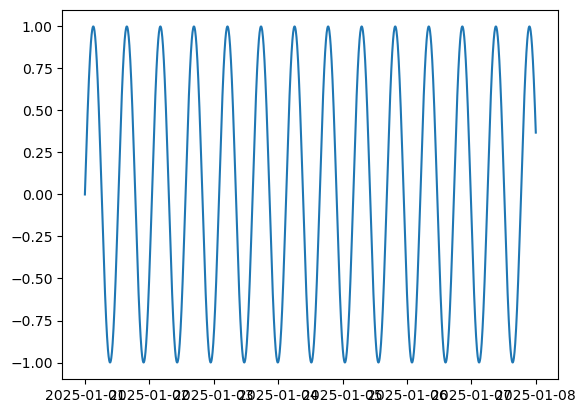

In [10]:
plt.plot(time,hydrodynamic_data.sel({'STATION':'1'})['Water level'].values)

In [11]:
# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph = graph, 
                                                                                crs_m="4087",
                                                                                hydrodynamic_information = hydrodynamic_data)

lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    levelling_time = 300,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    registration_nodes = ['-1','+1'],
)

start_time = pd.Timestamp('2025-01-01 00:00:00')

# Example using numpy
# Create independent random generators
rng_up = np.random.default_rng(123)
rng_down = np.random.default_rng(456)

# Exponential distributions with different means (scale = mean)
arrival_dist_up = lambda: rng_up.exponential(scale=30)   # mean 30 minutes
arrival_dist_down = lambda: rng_down.exponential(scale=15)  # mean 15 minutes

vessels = generate_vessels_with_distributions(
    env=env,
    num_vessels=40,
    start_time=start_time,
    arrival_dist_up=arrival_dist_up,
    arrival_dist_down=arrival_dist_down,
    seed_up=123,
    seed_down=456
)

for vessel in vessels:
    env.process(mission(env, vessel))
    
env.run()

Vessel 2 2025-01-01 00:07:22.177207 new
Vessel 4 2025-01-01 00:13:40.580269 planned
Vessel 6 2025-01-01 00:17:13.532738 planned
Vessel 1 2025-01-01 00:17:54.550491 new
Vessel 3 2025-01-01 00:21:25.206401 planned
Vessel 8 2025-01-01 00:24:37.704947 planned
Vessel 8 Vessel 1 0 days 00:07:57.124678
Vessel 8 Vessel 3 0 days 00:07:57.124678
Vessel 5 2025-01-01 00:28:58.436860 planned
Vessel 7 2025-01-01 00:38:12.774662 planned
Vessel 9 2025-01-01 00:40:58.019450 new
Vessel 10 2025-01-01 01:03:33.671764 new
Vessel 12 2025-01-01 01:04:18.150428 planned
Vessel 14 2025-01-01 01:07:47.987086 planned
Vessel 11 2025-01-01 01:51:30.936990 planned
Vessel 11 Vessel 10 0 days 00:06:32.980561764
Vessel 11 Vessel 12 0 days 00:06:32.980561764
Vessel 11 Vessel 14 0 days 00:06:32.980561764
Vessel 16 2025-01-01 01:55:15.583328 planned
Vessel 18 2025-01-01 02:09:14.395738 new
Vessel 20 2025-01-01 02:16:55.917207 planned
Vessel 22 2025-01-01 02:31:51.689261 planned
Vessel 24 2025-01-01 03:10:01.968400 planned

#### 4. Inspect output

In [12]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:07:22.177207,{},0
1,Lock doors closing stop,2025-01-01 00:12:22.177207,{},0
2,Lock chamber converting start,2025-01-01 00:12:22.177207,{},0
3,Lock chamber converting stop,2025-01-01 00:15:02.177207,{},0
4,Lock chamber converting start,2025-01-01 00:15:02.177207,{},0
...,...,...,...,...
99,Lock doors closing stop,2025-01-02 11:51:35.026766,{},0
100,Lock chamber converting start,2025-01-02 11:51:35.026766,{},0
101,Lock chamber converting stop,2025-01-02 12:12:05.026766,{},1
102,Lock doors opening start,2025-01-02 12:12:05.026766,{},1


#### Gantt chart of event table

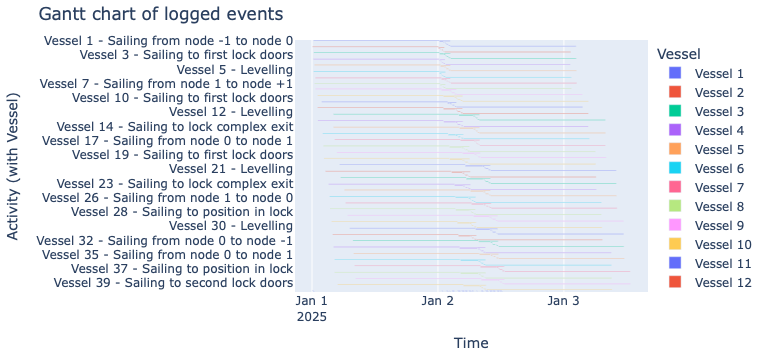

In [13]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock])
fig = generate_vessel_gantt_chart(df_eventtable)

#### Time-distance diagram of vessels passing the lock and planning info

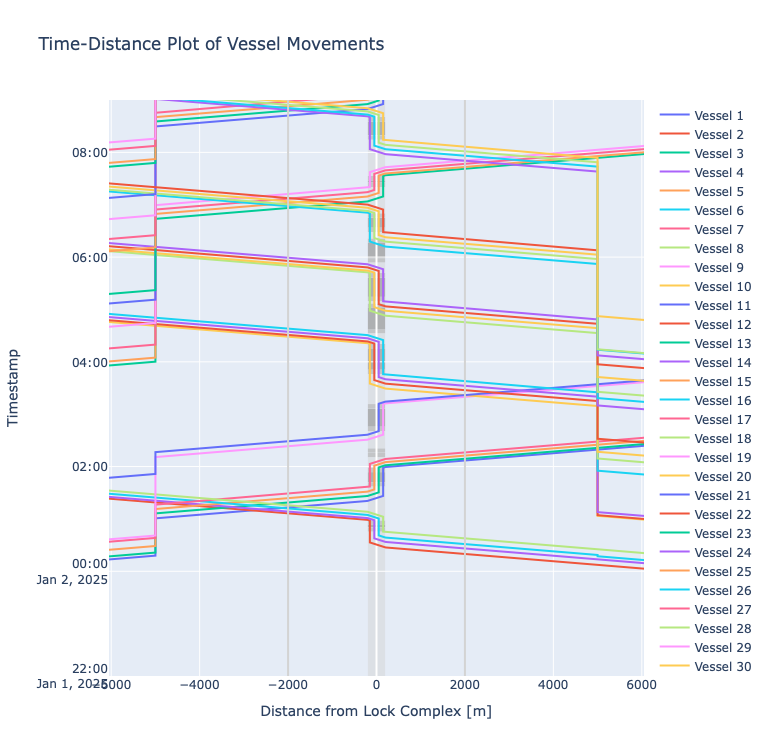

In [14]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock.create_time_distance_plot(vessels = vessels, 
                                     xlimmin = -6050, 
                                     xlimmax = 6050,
                                     ylimmin = pd.Timestamp('2025-01-01 22:00:00'),
                                     ylimmax = pd.Timestamp('2025-01-02 09:00:00'),
                                     method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

In [15]:
lock.vessel_planning

,id,bound,L,B,T,operation_index,time_of_registration,time_of_acceptance,time_arrival_at_waiting_area,time_arrival_at_lineup_area,time_lock_passing_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_passing_stop,delay,time_potential_lock_door_opening_stop,time_potential_lock_door_closure_start
0,35ef103a-3ec0-43f9-8235-f9ac0a45b8c1,1,100,20,10,1,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-02 00:07:22.177207,NaN,2025-01-02 00:19:52.177207,2025-01-02 00:27:22.177207,2025-01-02 00:33:02.349993470,2025-01-02 00:56:43.493284058,2025-01-02 00:57:32.089396410,2025-01-02 01:05:02.089396410,0 days 00:13:31.143290588,2025-01-02 00:17:22.177207000,2025-01-02 00:33:02.349993470
1,2a1232fa-2ace-4f36-b785-753b1be2504d,1,100,20,10,1,2025-01-01 00:13:40.580269,2025-01-01 00:13:40.580269,2025-01-02 00:13:40.580269,NaN,2025-01-02 00:26:10.580269,2025-01-02 00:33:40.580269,2025-01-02 00:37:43.560830764,2025-01-02 00:57:06.301059352,2025-01-02 00:59:32.089396410,2025-01-02 01:07:02.089396410,0 days 00:04:19.932453294,2025-01-02 00:23:40.580269000,2025-01-02 00:37:43.560830764
2,8a6f8fda-9c53-407b-9cbf-adcdf29748cc,1,100,20,10,1,2025-01-01 00:17:13.532738,2025-01-01 00:17:13.532738,2025-01-02 00:17:13.532738,NaN,2025-01-02 00:31:10.580269,2025-01-02 00:38:40.580269,2025-01-02 00:41:06.368606058,2025-01-02 00:57:59.108834646,2025-01-02 01:02:02.089396410,2025-01-02 01:09:32.089396410,0 days 00:04:19.932453294,2025-01-02 00:28:40.580269000,2025-01-02 00:41:06.368606058
3,3804dd92-cc46-4727-b6f3-252d77c5aff8,0,100,20,10,2,2025-01-01 00:17:54.550491,2025-01-01 00:17:54.550491,2025-01-02 00:17:54.550491,NaT,2025-01-02 01:13:09.281621116,2025-01-02 01:20:39.281621116,2025-01-02 01:26:19.454407586,2025-01-02 01:58:38.050519938,2025-01-02 01:59:26.646632290,2025-01-02 02:06:56.646632290,0 days 00:57:13.327242468,2025-01-02 01:10:39.281621116,2025-01-02 01:26:19.454407586
4,8f7ba678-b919-4d5a-a205-98054b5e7afe,0,100,20,10,2,2025-01-01 00:21:25.206401,2025-01-01 00:21:25.206401,2025-01-02 00:21:25.206401,NaT,2025-01-02 01:18:49.454407586,2025-01-02 01:26:19.454407586,2025-01-02 01:30:22.434969350,2025-01-02 01:59:00.858295232,2025-01-02 02:01:26.646632290,2025-01-02 02:08:56.646632290,0 days 00:18:22.740228588,2025-01-02 01:16:19.454407586,2025-01-02 01:30:22.434969350
5,ed8a52eb-59a9-44f3-bf19-13d0589106c1,1,100,20,10,1,2025-01-01 00:24:37.704947,2025-01-01 00:24:37.704947,2025-01-02 00:24:37.704947,NaN,2025-01-02 00:37:07.704947,2025-01-02 00:44:37.704947,2025-01-02 00:45:26.301059352,2025-01-02 00:59:59.108834646,2025-01-02 01:05:39.281621116,2025-01-02 01:13:09.281621116,0 days 00:00:00,2025-01-02 00:34:37.704947000,2025-01-02 00:45:26.301059352
6,5e689b94-3e86-4331-aefa-896492f74c1e,0,100,20,10,2,2025-01-01 00:28:58.436860,2025-01-01 00:28:58.436860,2025-01-02 00:28:58.436860,NaN,2025-01-02 01:23:49.454407586,2025-01-02 01:31:19.454407586,2025-01-02 01:33:45.242744644,2025-01-02 02:01:00.858295232,2025-01-02 02:05:03.838856996,2025-01-02 02:12:33.838856996,0 days 00:03:22.807775294,2025-01-02 01:21:19.454407586,2025-01-02 01:33:45.242744644
7,7fd0e848-010d-4984-80d6-6a7fe861935f,0,100,20,10,2,2025-01-01 00:38:12.774662,2025-01-01 00:38:12.774662,2025-01-02 00:38:12.774662,NaN,2025-01-02 01:28:49.454407586,2025-01-02 01:36:19.454407586,2025-01-02 01:37:08.050519938,2025-01-02 02:03:00.858295232,2025-01-02 02:08:41.031081702,2025-01-02 02:16:11.031081702,0 days 00:00:00,2025-01-02 01:26:19.454407586,2025-01-02 01:37:08.050519938
8,0706f7d7-90a0-4cf3-ac90-e39433e593b2,0,100,20,10,4,2025-01-01 00:40:58.019450,2025-01-01 00:40:58.019450,2025-01-02 00:40:58.019450,NaN,2025-01-02 02:23:21.031081702,2025-01-02 02:30:51.031081702,2025-01-02 02:36:31.203868172,2025-01-02 03:11:34.184429936,2025-01-02 03:12:22.780542288,2025-01-02 03:19:52.780542288,0 days 01:34:25.992193466,2025-01-02 02:20:51.031081702,2025-01-02 02:36:31.203868172
9,419288eb-947b-4204-b3d3-5cb1d7fce50e,1,100,20,10,5,20

In [16]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[],400,50,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:07:22.177207,2025-01-01 00:12:22.177207,...,2025-01-01 00:20:02.177207,2025-01-01 00:20:02.177207,2025-01-01 00:20:02.177207,2025-01-01 00:20:02.177207,2025-01-01 00:20:02.177207,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
1,1,"[<__main__.Vessel object at 0x175df9510>, <__m...",0,-30,2025-01-02 00:17:22.177207,2025-01-02 00:19:52.177207,2025-01-02 00:27:22.177207,2025-01-02 00:45:26.301059352,2025-01-02 00:45:26.301059352,2025-01-02 00:50:26.301059352,...,2025-01-02 00:55:36.301059352,2025-01-02 00:55:36.301059352,2025-01-02 01:05:39.281621116,2025-01-02 01:13:09.281621116,2025-01-02 01:07:39.281621116,NaN,NaN,0 days 00:13:31.143290588,0 days 00:22:11.008197176,unavailable
2,0,"[<__main__.Vessel object at 0x1763d0fd0>, <__m...",0,-30,2025-01-02 01:10:39.281621116,2025-01-02 01:13:09.281621116,2025-01-02 01:20:39.281621116,2025-01-02 01:37:08.050519938,2025-01-02 01:37:08.050519938,2025-01-02 01:42:08.050519938,...,2025-01-02 01:58:38.050519938,2025-01-02 01:58:38.050519938,2025-01-02 02:08:41.031081702,2025-01-02 02:16:11.031081702,2025-01-02 02:10:41.031081702,NaN,NaN,0 days 00:57:13.327242468,0 days 01:18:58.875246350,unavailable
3,1,[],400,50,2025-01-02 02:10:41.031081702,2025-01-02 02:10:41.031081702,2025-01-02 02:10:41.031081702,2025-01-02 02:10:41.031081702,2025-01-02 02:10:41.031081702,2025-01-02 02:15:41.031081702,...,2025-01-02 02:20:51.031081702,2025-01-02 02:20:51.031081702,2025-01-02 02:20:51.031081702,2025-01-02 02:20:51.031081702,2025-01-02 02:20:51.031081702,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
4,0,"[<__main__.Vessel object at 0x177a6f410>, <__m...",200,10,2025-01-02 02:20:51.031081702,2025-01-02 02:23:21.031081702,2025-01-02 02:30:51.031081702,2025-01-02 02:40:34.184429936,2025-01-02 02:40:34.184429936,2025-01-02 02:45:34.184429936,...,2025-01-02 03:11:34.184429936,2025-01-02 03:11:34.184429936,2025-01-02 03:14:22.780542288,2025-01-02 03:21:52.780542288,2025-01-02 03:16:22.780542288,NaN,NaN,0 days 01:34:25.992193466,0 days 01:34:25.992193466,unavailable
5,1,"[<__main__.Vessel object at 0x177a67cd0>, <__m...",0,-30,2025-01-02 03:19:22.780542288,2025-01-02 03:21:52.780542288,2025-01-02 03:29:22.780542288,2025-01-02 03:45:51.549441110,2025-01-02 03:45:51.549441110,2025-01-02 03:50:51.549441110,...,2025-01-02 03:56:01.549441110,2025-01-02 03:56:01.549441110,2025-01-02 04:06:04.530002874,2025-01-02 04:13:34.530002874,2025-01-02 04:08:04.530002874,NaN,NaN,0 days 02:37:34.897115346,0 days 03:42:43.666014168,unavailable
6,0,[],400,50,2025-01-02 04:08:04.530002874,2025-01-02 04:08:04.530002874,2025-01-02 04:08:04.530002874,2025-01-02 04:08:04.530002874,2025-01-02 04:08:04.530002874,2025-01-02 04:13:04.530002874,...,2025-01-02 04:42:54.530002874,2025-01-02 04:42:54.530002874,2025-01-02 04:42:54.530002874,2025-01-02 04:42:54.530002874,2025-01-02 04:42:54.530002874,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
7,1,"[<__main__.Vessel object at 0x177a8ca90>, <__m...",0,-30,2025-01-02 04:42:54.530002874,2025-01-02 04:45:24.530002874,2025-01-02 04:52:54.530002874,2025-01-02 05:09:23.298901696,2025-01-02 05:09:23.298901696,2025-01-02 05:14:23.298901696,...,2025-01-02 05:19:33.298901696,2025-01-02 05:19:33.298901696,2025-01-02 05:29:36.279463460,2025-01-02 05:37:06.279463460,2025-01-02 05:31:36.279463460,NaN,NaN,0 days 02:34:28.730377226,0 days 02:44:37.153703108,unavailable
8,0,[],400,50,2025-01-02 05:31:36.279463460,2025-01-02 05:31:36.279463460,2025-01-02 05:31:36.279463460,2025-0

In [17]:
lock.operation_planning.apply(lambda x: [vessel.name for vessel in (x.vessels)], axis=1)

lock_operation
0                                               []
1         [Vessel 2, Vessel 4, Vessel 6, Vessel 8]
2         [Vessel 1, Vessel 3, Vessel 5, Vessel 7]
3                                               []
4                            [Vessel 9, Vessel 11]
5     [Vessel 10, Vessel 12, Vessel 14, Vessel 16]
6                                               []
7     [Vessel 18, Vessel 20, Vessel 22, Vessel 24]
8                                               []
9     [Vessel 26, Vessel 28, Vessel 30, Vessel 32]
10    [Vessel 13, Vessel 15, Vessel 17, Vessel 19]
11    [Vessel 34, Vessel 36, Vessel 38, Vessel 40]
12    [Vessel 21, Vessel 23, Vessel 25, Vessel 27]
13                                              []
14    [Vessel 29, Vessel 31, Vessel 33, Vessel 35]
15                                              []
16                          [Vessel 37, Vessel 39]
dtype: object

#### Levelling times as a function of water levels

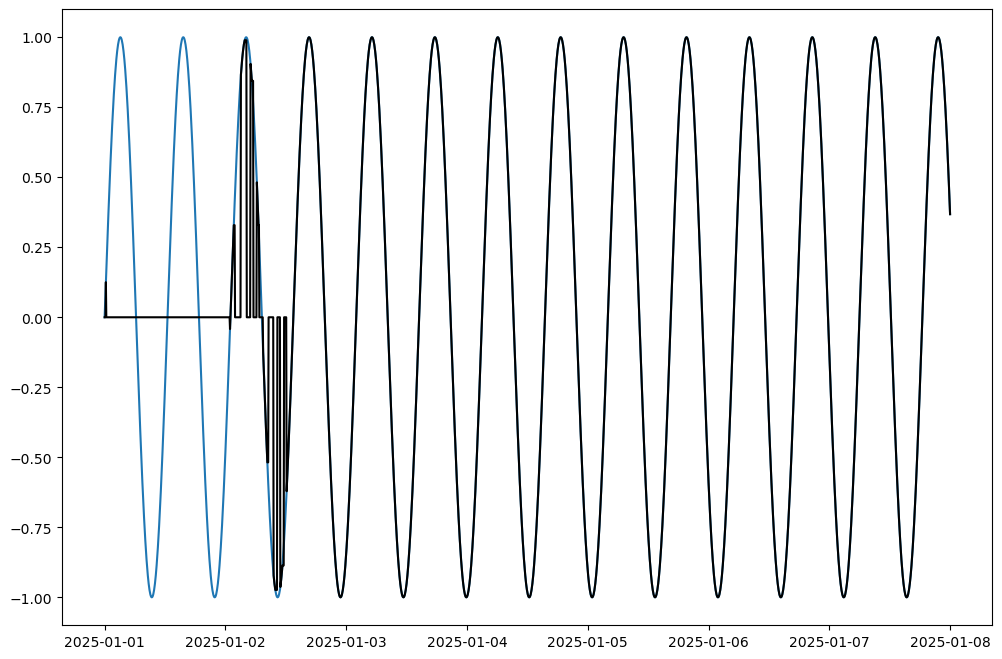

In [18]:
fig,ax = plt.subplots(figsize=[12,8])
ax.plot(hydrodynamic_data["TIME"],hydrodynamic_data.sel({'STATION':'1'})["Water level"])
ax.plot(hydrodynamic_data["TIME"],lock.water_level,color='k')

In [19]:
levelling_times = []
water_level_difference = []
stationA_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock.start_node)[0][0]
stationB_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock.end_node)[0][0]
H_A = hydrodynamic_data["Water level"][stationA_index].values.copy()
H_B = hydrodynamic_data["Water level"][stationB_index].values.copy()
for time in pd.date_range(pd.Timestamp('2025-01-01T00:00:00.000000000'),pd.Timestamp('2025-01-01T12:30:00.000000000'),freq=pd.Timedelta(minutes=5)):
    time_index = np.absolute(hydrodynamic_data['TIME'][:].values - np.datetime64(time)).argmin()
    wlev_A = H_A[time_index]
    wlev_B = H_B[time_index]
    wlev_dif = wlev_A - wlev_B
    water_level_difference.append(wlev_dif)
    levelling_times.append(lock.determine_levelling_time(time,direction=1,wlev_init=wlev_dif,prediction=True)[0])

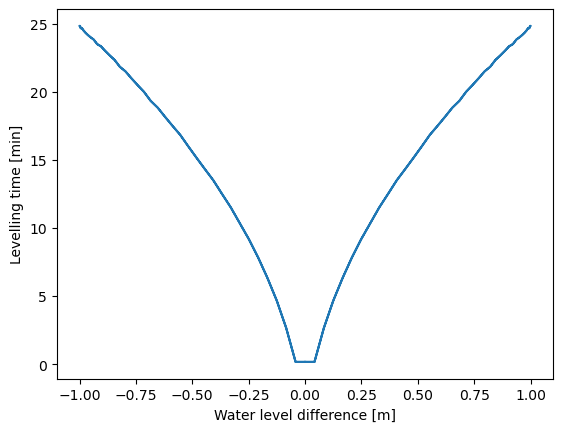

In [20]:
plt.plot(water_level_difference,np.array(levelling_times)/60)
plt.xlabel('Water level difference [m]')
plt.ylabel('Levelling time [min]');